In [1]:
from google.colab import files # чтобы загружать файлы в облако через проводник

In [2]:
uploaded = files.upload()#просто запускаем и выбираем файл  API токена в проводнике

#↓ строка которая активирует наш API токен
!mkdir -p ~/.kaggle/ && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [3]:
!kaggle competitions download -c urfusf2024clustering

  0% 0.00/953k [00:00<?, ?B/s]
100% 953k/953k [00:00<00:00, 979MB/s]


In [4]:
!unzip urfusf2024clustering.zip

Archive:  urfusf2024clustering.zip
  inflating: Data.csv                
  inflating: Submission.csv          


In [5]:
import pandas as pd # Библиотека Pandas для работы с табличными данными

Размерность данных: (19033, 5)

Статистическое описание данных:
          Признак 1     Признак 2     Признак 3     Признак 4     Признак 5
count  1.903300e+04  1.903300e+04  1.903300e+04  1.903300e+04  1.903300e+04
mean   1.567950e-17  5.039840e-17 -8.922383e-17  1.657547e-16  3.434557e-17
std    5.372720e-01  6.612815e-02  6.395875e-02  4.809839e-01  5.676626e-02
min   -8.865561e-01 -4.705258e-02 -3.499009e-01 -5.417184e-01 -3.695438e-01
25%   -2.556412e-01 -1.392043e-02 -2.251187e-02 -4.636834e-01 -1.943088e-02
50%   -1.527072e-01 -9.348055e-03  3.760155e-03 -1.193854e-01  2.740698e-03
75%    1.387202e-01 -5.841646e-03  2.707801e-02  3.591970e-01  2.958351e-02
max    1.048308e+00  9.805234e-01  3.976242e-01  1.067578e+00  4.547306e-01

Проверка на пропуски:
Признак 1    0
Признак 2    0
Признак 3    0
Признак 4    0
Признак 5    0
dtype: int64


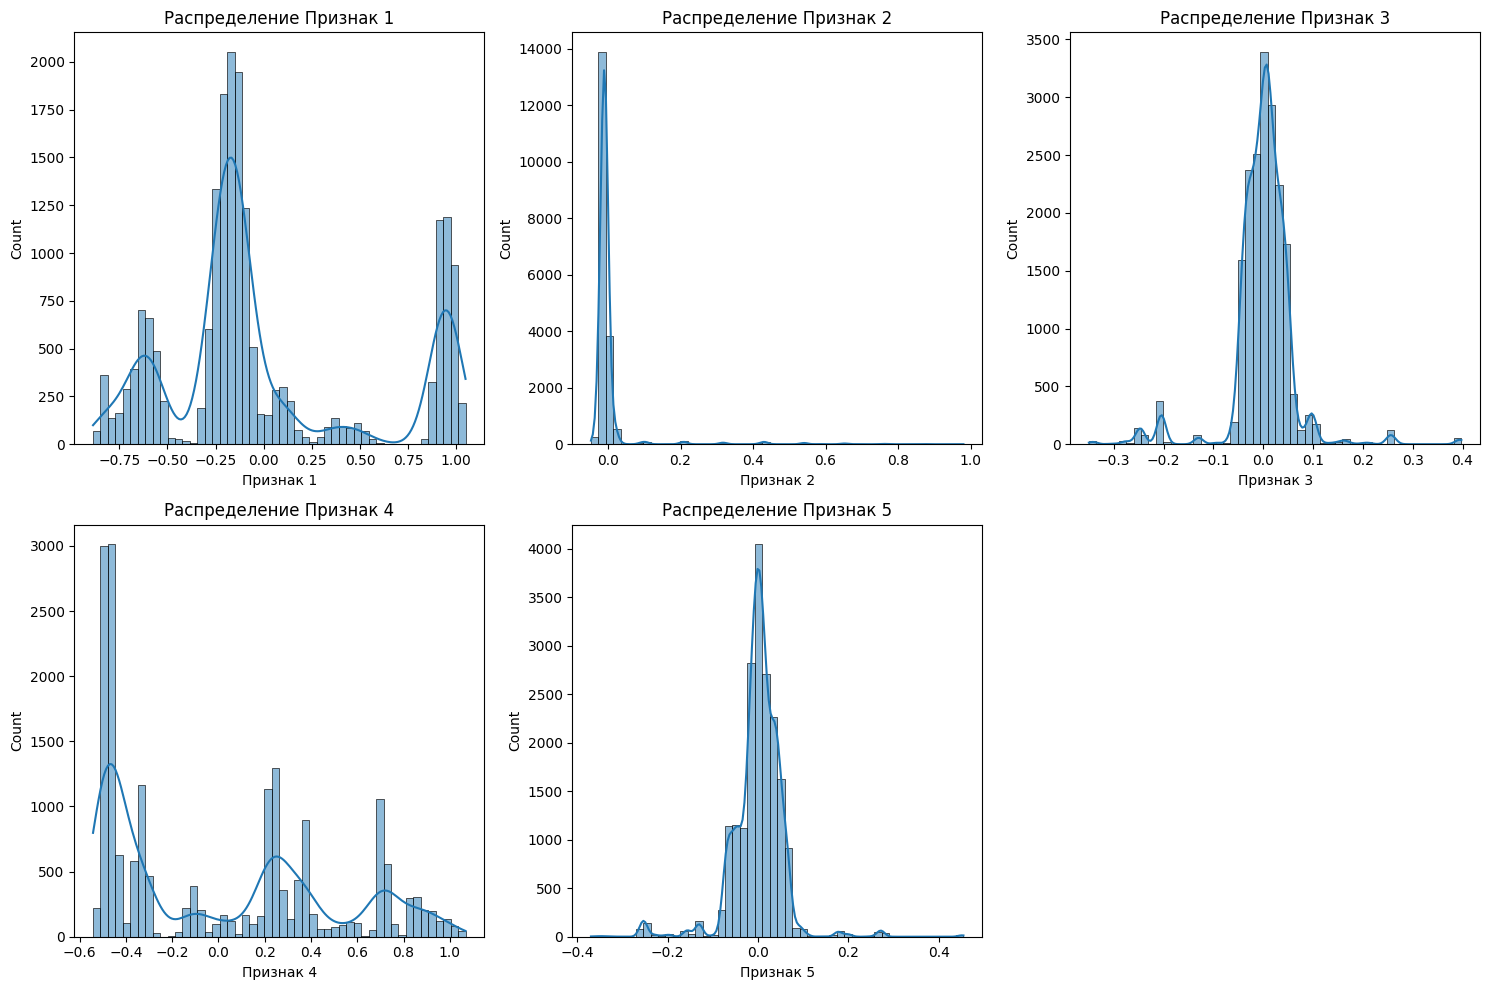

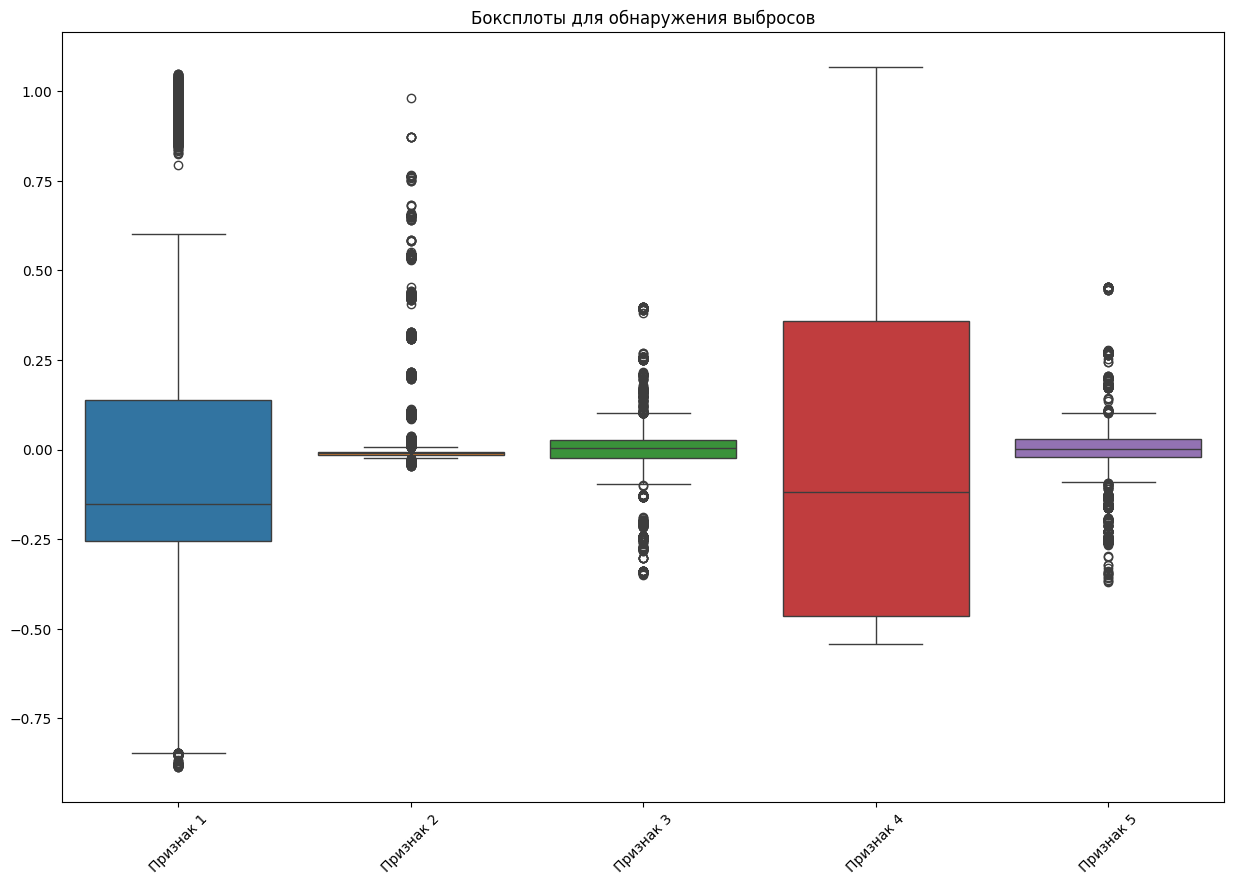

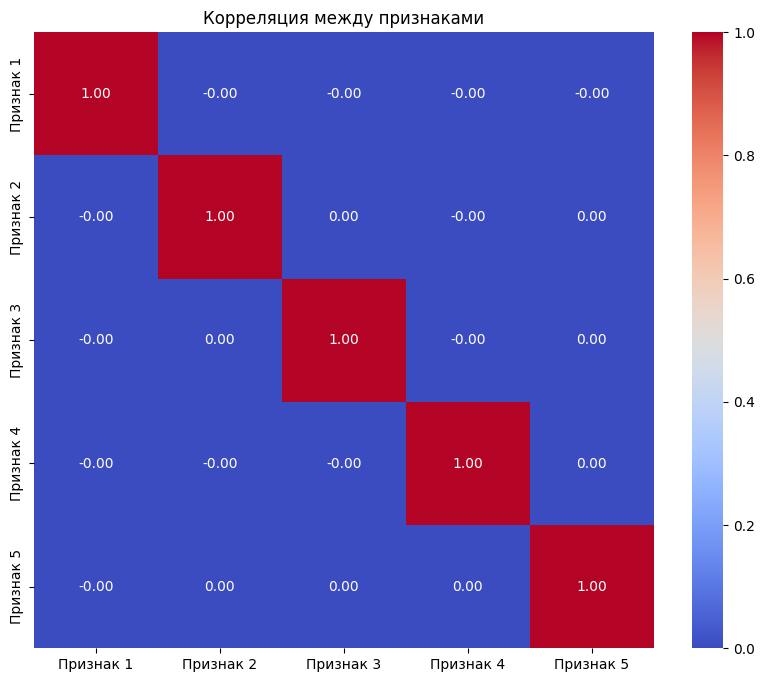

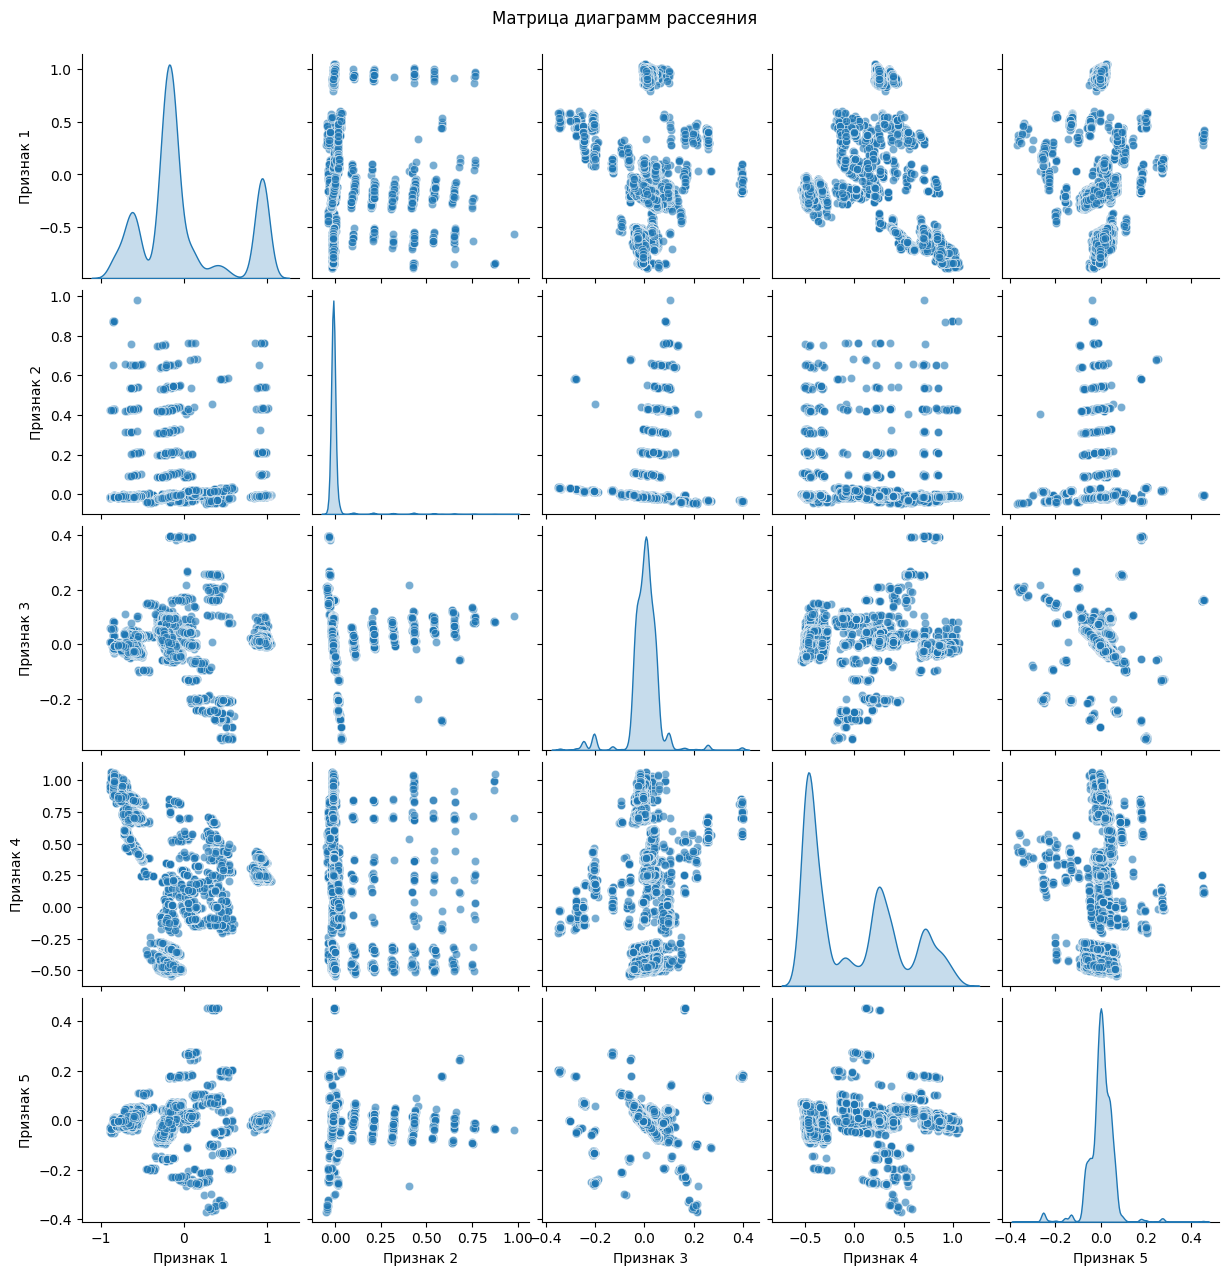


Важность признаков для PCA с StandardScaler:
Признак 1: PC1 = -0.100, PC2 = -0.154
Признак 2: PC1 = 0.834, PC2 = -0.063
Признак 3: PC1 = 0.163, PC2 = -0.534
Признак 4: PC1 = 0.209, PC2 = 0.823
Признак 5: PC1 = 0.474, PC2 = -0.101

Важность признаков для PCA с RobustScaler:
Признак 1: PC1 = -0.000, PC2 = 1.000
Признак 2: PC1 = 1.000, PC2 = 0.000
Признак 3: PC1 = 0.000, PC2 = -0.000
Признак 4: PC1 = 0.000, PC2 = -0.000
Признак 5: PC1 = 0.000, PC2 = -0.000

Важность признаков для PCA с MinMaxScaler:
Признак 1: PC1 = 0.000, PC2 = 1.000
Признак 2: PC1 = 0.000, PC2 = -0.000
Признак 3: PC1 = 0.000, PC2 = 0.000
Признак 4: PC1 = 1.000, PC2 = -0.000
Признак 5: PC1 = 0.000, PC2 = 0.000


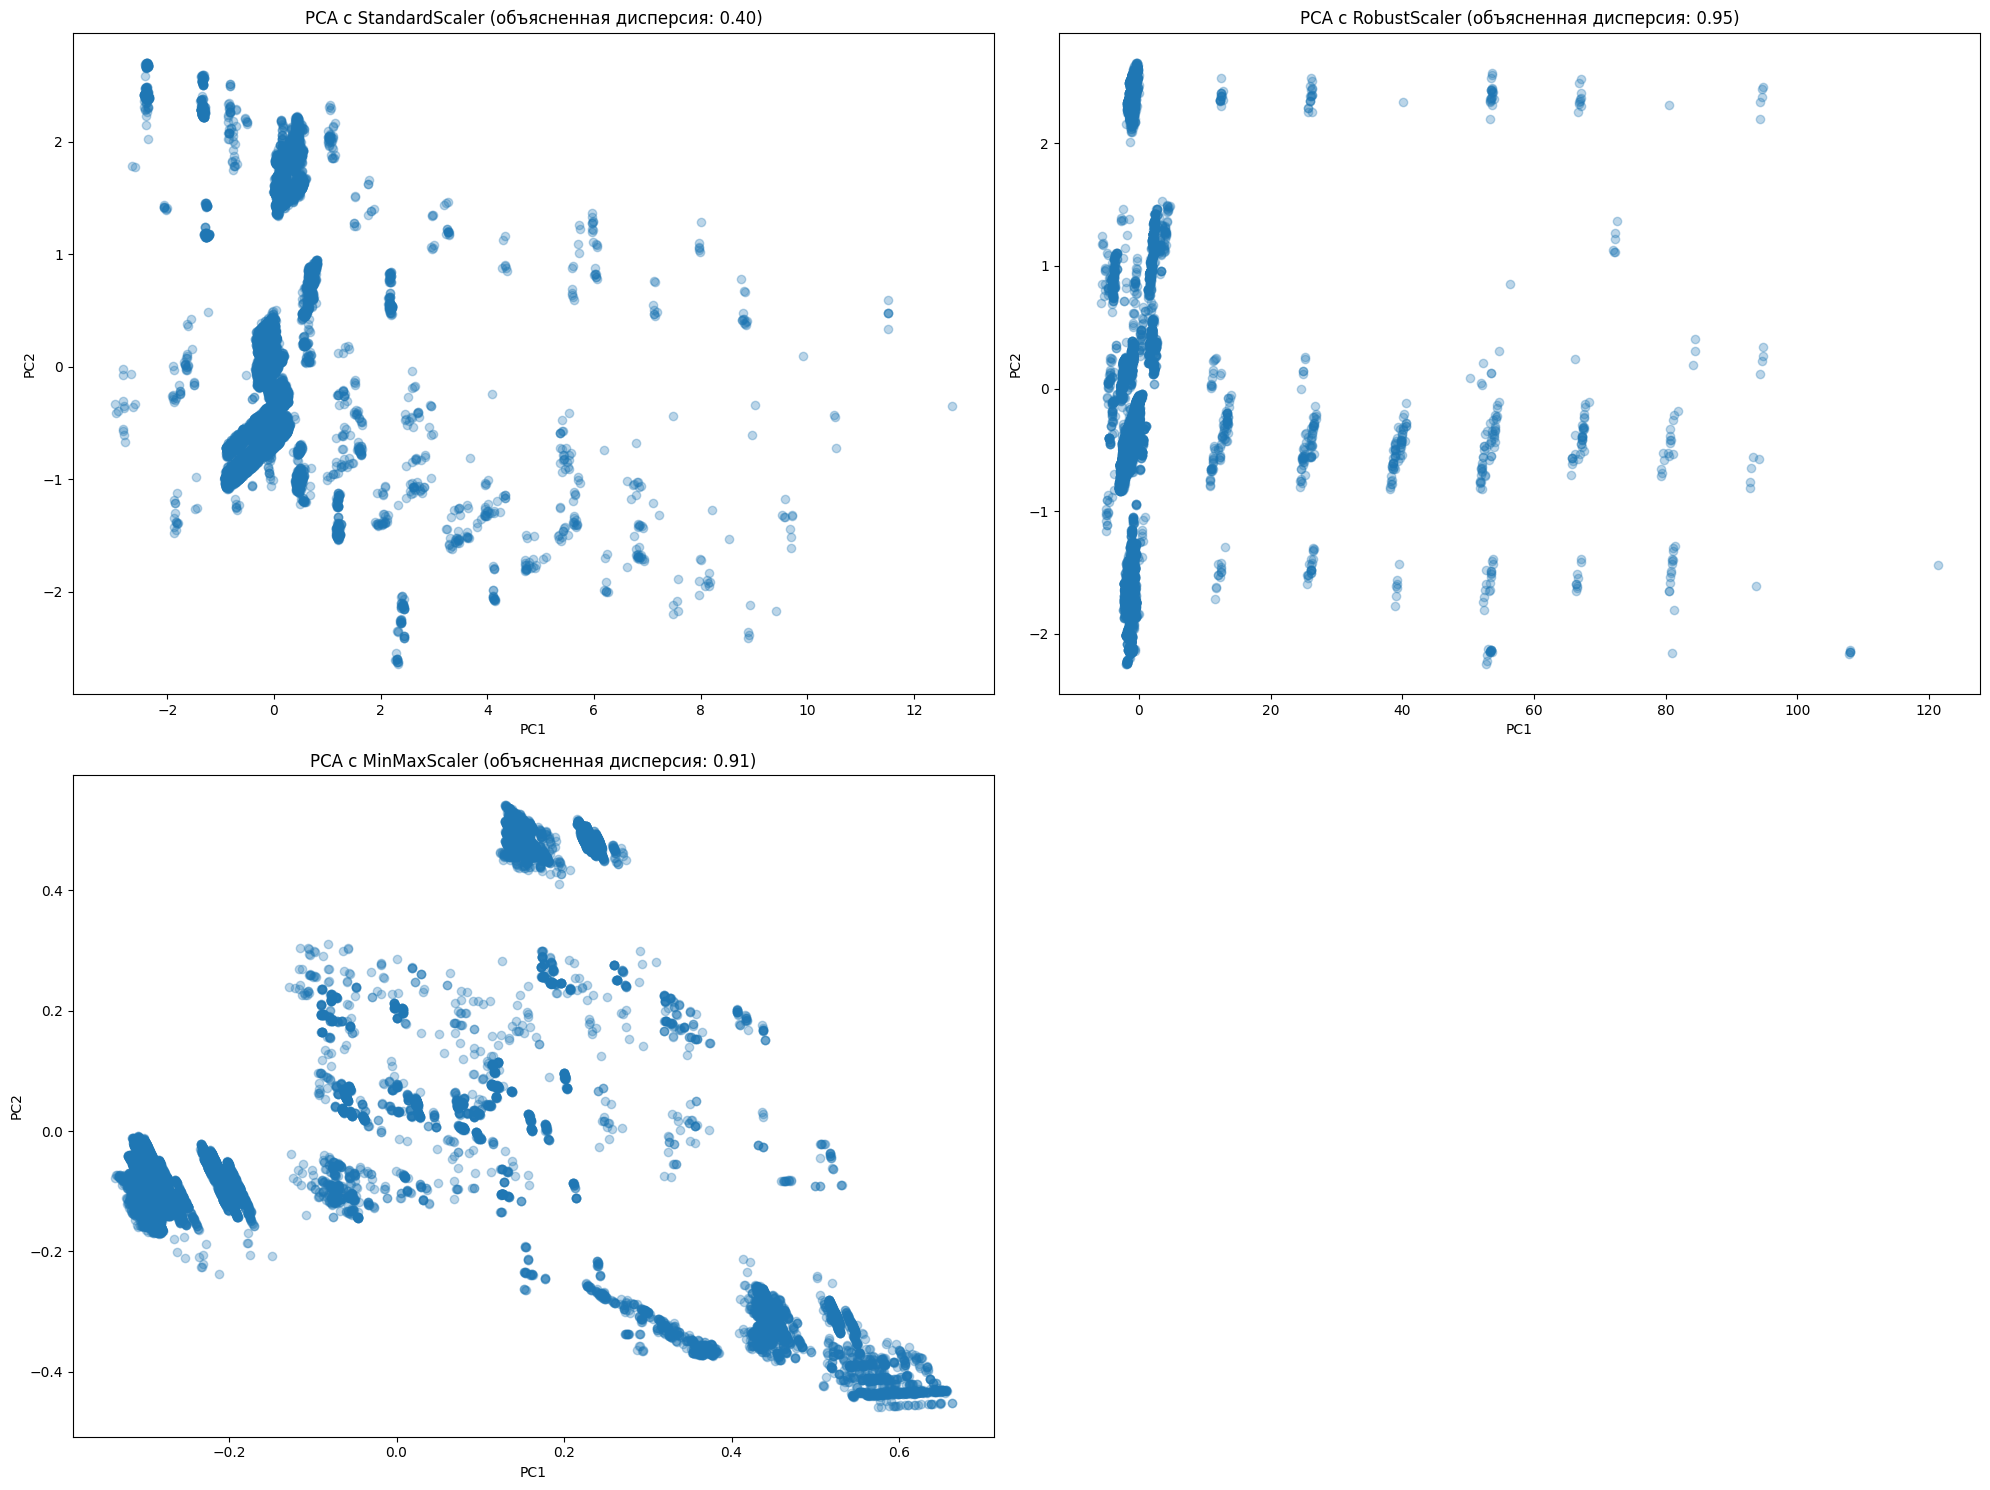

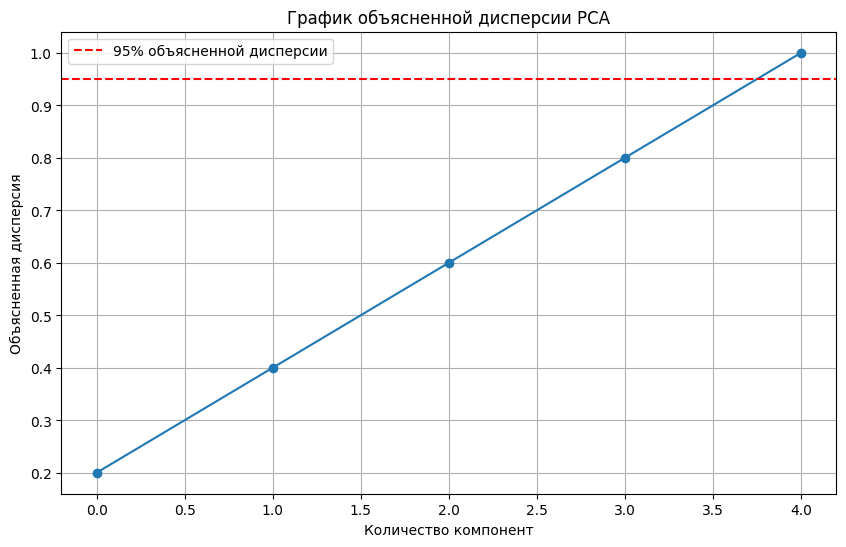

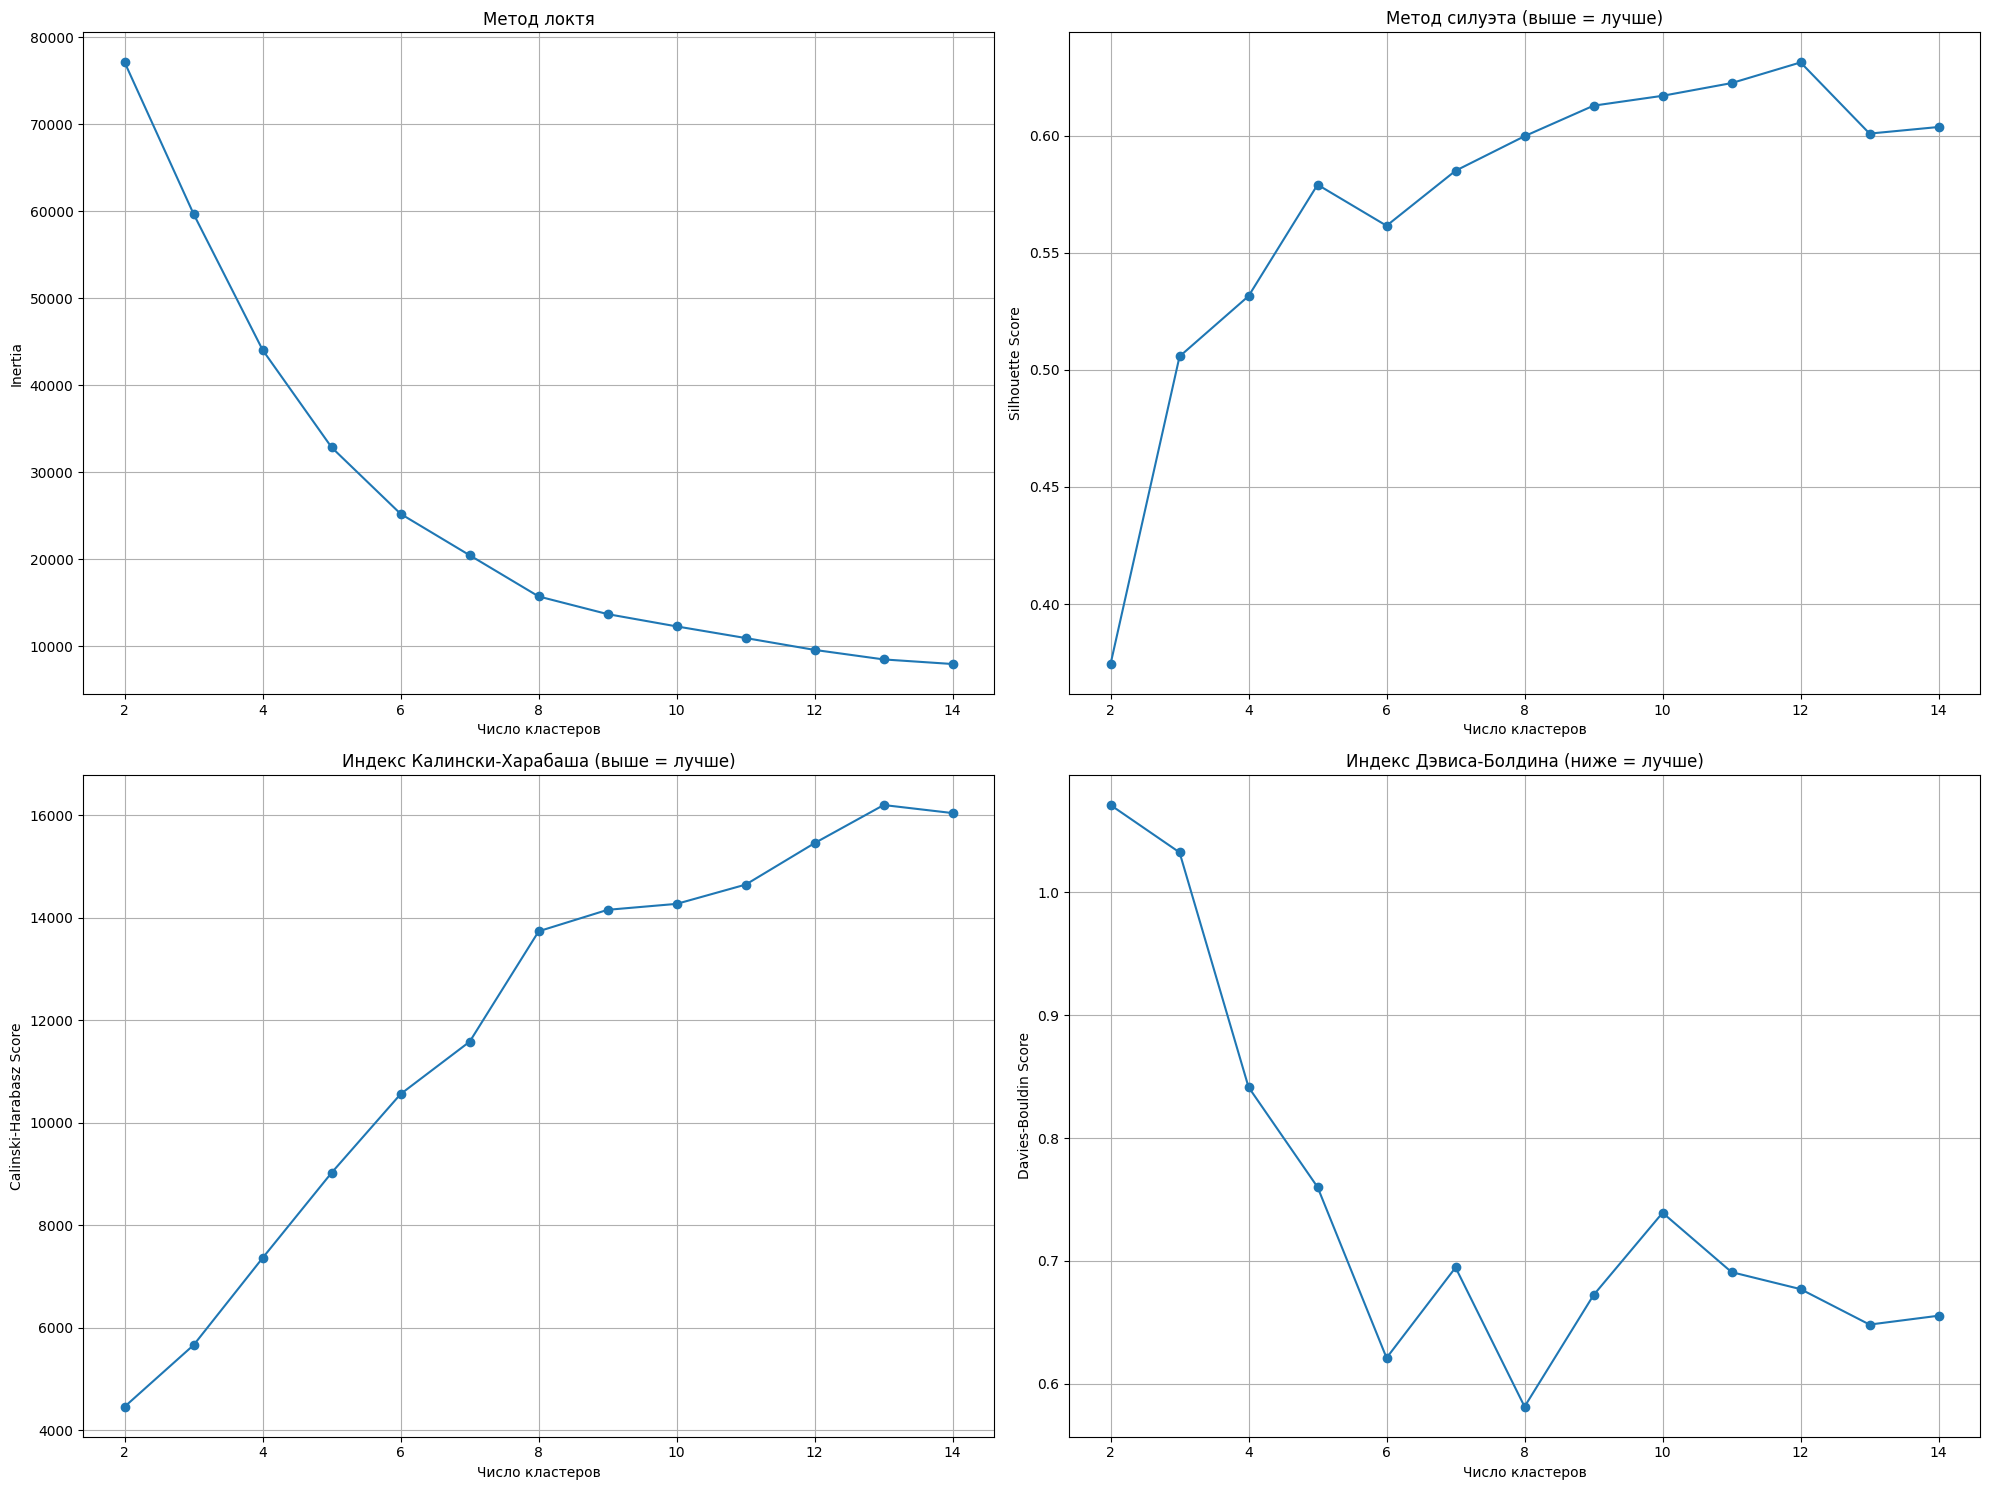


Результаты для KMeans:
Силуэт: 0.531
Калински-Харабаш: 7365.718
Дэвис-Болдин: 0.841
Распределение меток: {0: 10342, 1: 4662, 2: 3729, 3: 300}

Результаты для AgglomerativeClustering:
Силуэт: 0.523
Калински-Харабаш: 7117.831
Дэвис-Болдин: 0.814
Распределение меток: {0: 3998, 1: 3972, 2: 10742, 3: 321}

Результаты для SpectralClustering:
Силуэт: 0.686
Калински-Харабаш: 159.863
Дэвис-Болдин: 0.251
Распределение меток: {0: 19005, 1: 3, 2: 7, 3: 18}

Результаты для GaussianMixture:
Силуэт: 0.520
Калински-Харабаш: 4491.217
Дэвис-Болдин: 2.045
Распределение меток: {0: 3913, 1: 3783, 2: 1954, 3: 9383}

Лучший алгоритм по Silhouette Score: SpectralClustering с оценкой 0.686

Размеры кластеров (от наибольшего к наименьшему):
0    19005
3       18
2        7
1        3
Name: count, dtype: int64


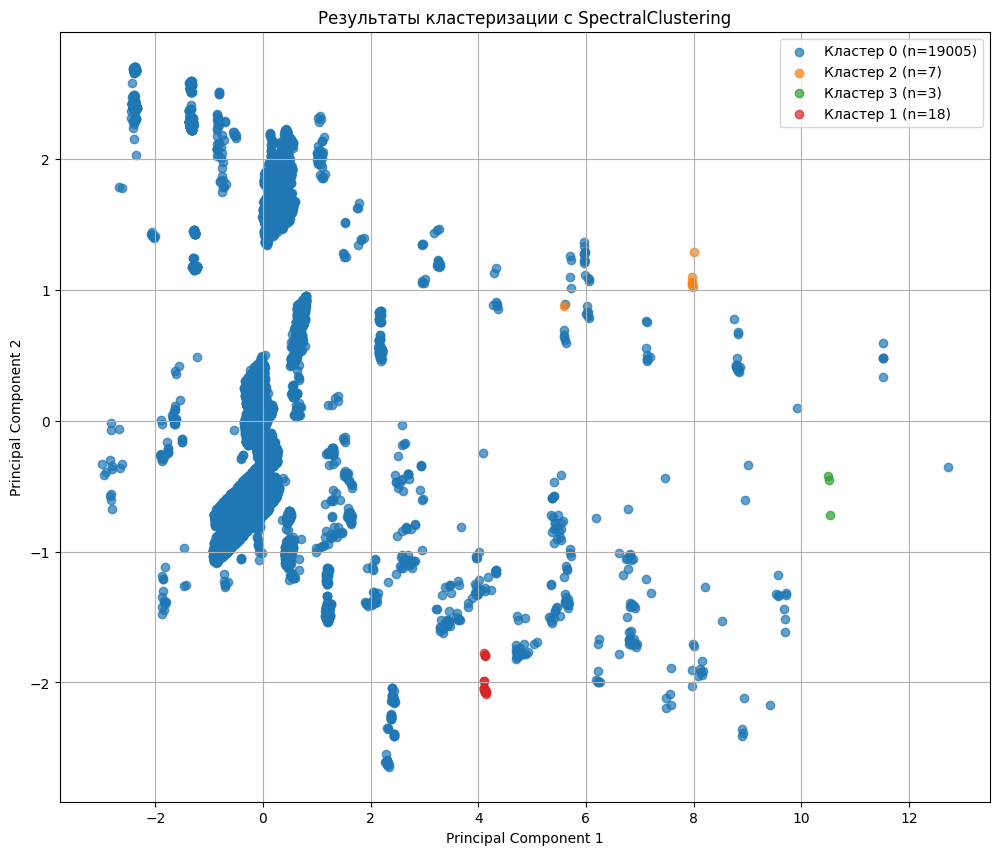

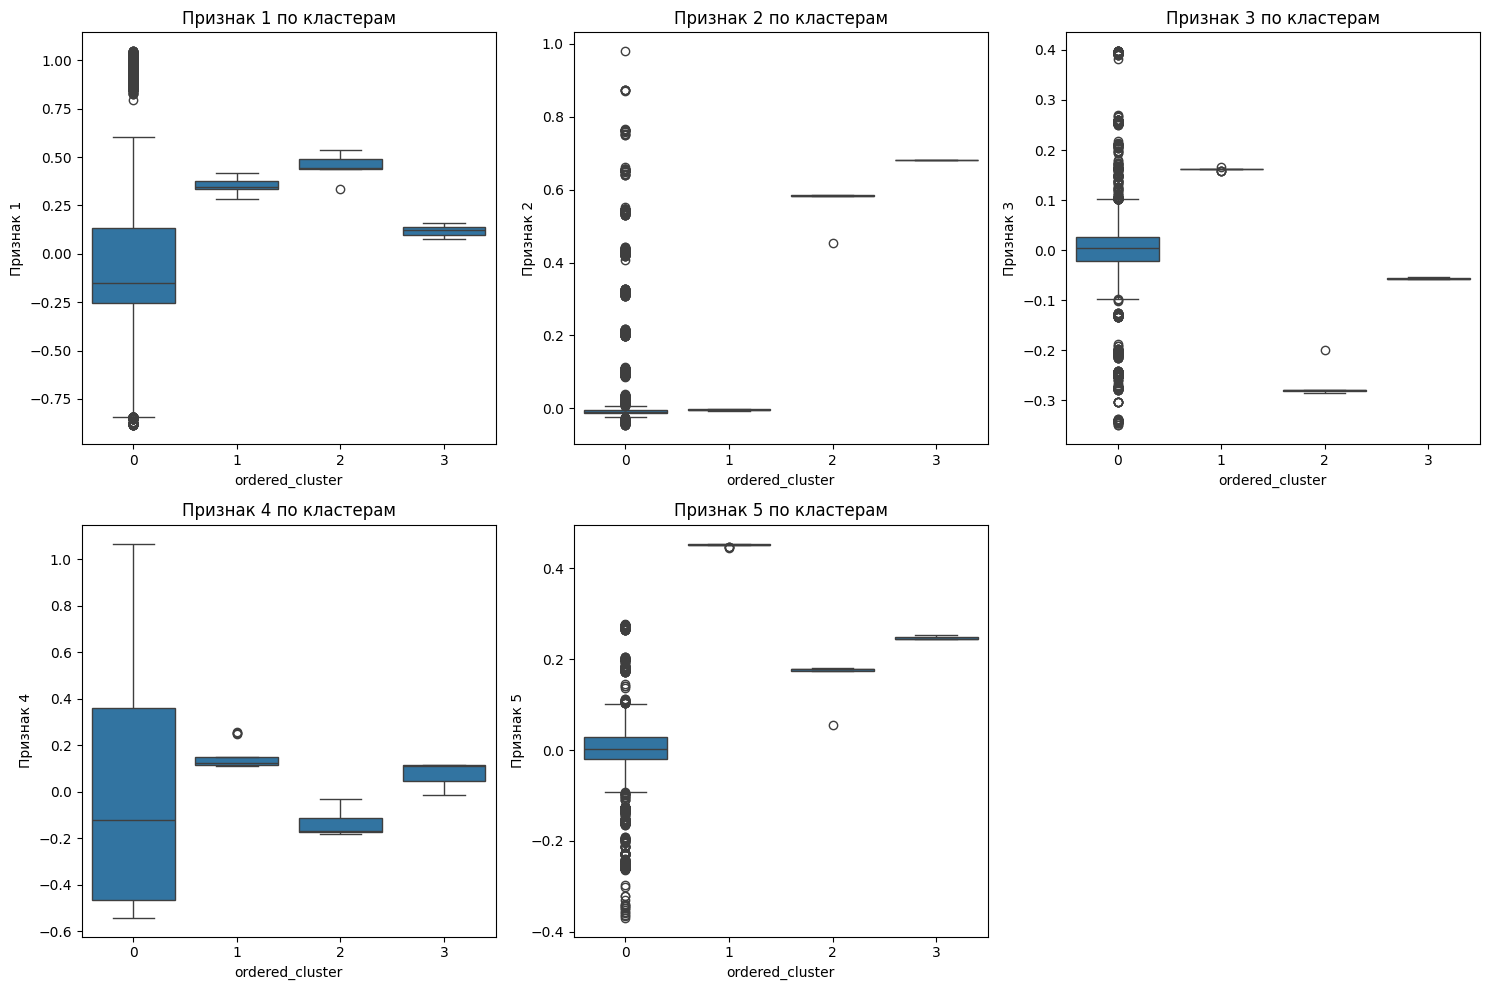


Средние значения признаков по кластерам:
                 Признак 1  Признак 2  Признак 3  Признак 4  Признак 5  \
ordered_cluster                                                          
0                -0.000520  -0.000312  -0.000045  -0.000105  -0.000526   
1                 0.352494  -0.004570   0.161499   0.151072   0.451302   
2                 0.454038   0.565384  -0.269087  -0.134807   0.160372   
3                 0.118102   0.681701  -0.056449   0.070725   0.247078   

                 cluster  
ordered_cluster           
0                    0.0  
1                    3.0  
2                    2.0  
3                    1.0  


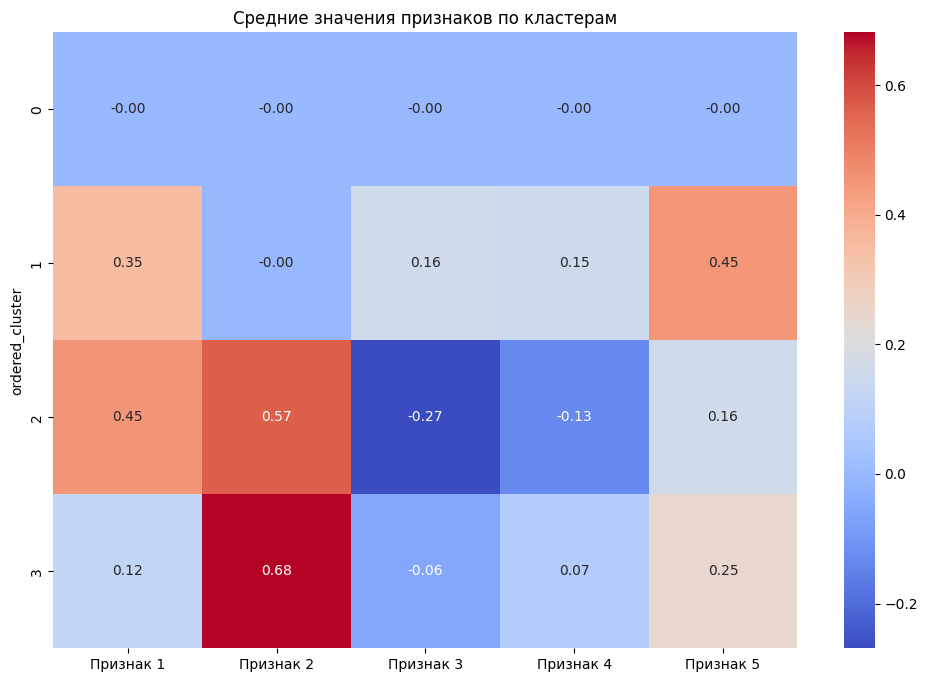


Распределение кластеров в итоговой отправке:
label
0    19005
1       18
2        7
3        3
Name: count, dtype: int64


In [6]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.mixture import GaussianMixture
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
DF = pd.read_csv('/content/Data.csv', delimiter=',', index_col='idx')
Submission = pd.read_csv('/content/Submission.csv', delimiter=',', index_col='idx')

# 1. Расширенный исследовательский анализ данных (EDA)
print("Размерность данных:", DF.shape)
print("\nСтатистическое описание данных:")
print(DF.describe())

print("\nПроверка на пропуски:")
print(DF.isnull().sum())

# Визуализация распределения признаков
plt.figure(figsize=(15, 10))
for i, col in enumerate(DF.columns):
    plt.subplot(2, 3, i+1)
    sns.histplot(DF[col], kde=True, bins=50)
    plt.title(f'Распределение {col}')
plt.tight_layout()
plt.show()

# Боксплоты для обнаружения выбросов
plt.figure(figsize=(15, 10))
sns.boxplot(data=DF)
plt.title('Боксплоты для обнаружения выбросов')
plt.xticks(rotation=45)
plt.show()

# Корреляционная матрица
plt.figure(figsize=(10, 8))
corr_matrix = DF.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция между признаками')
plt.show()

# Анализ парных зависимостей
sns.pairplot(DF, diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Матрица диаграмм рассеяния', y=1.02)
plt.show()

# 2. Более продвинутая предобработка данных
# Попробуем разные скейлеры, выберем наилучший
scalers = {
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler(),
    'MinMaxScaler': MinMaxScaler()
}

scaled_data = {}
for name, scaler in scalers.items():
    scaled_data[name] = scaler.fit_transform(DF)

# 3. Анализ главных компонент для всех скейлеров
plt.figure(figsize=(20, 15))
for i, (name, data) in enumerate(scaled_data.items()):
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(data)

    plt.subplot(2, 2, i+1)
    plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.3)
    plt.title(f'PCA с {name} (объясненная дисперсия: {sum(pca.explained_variance_ratio_):.2f})')
    plt.xlabel('PC1')
    plt.ylabel('PC2')

    print(f"\nВажность признаков для PCA с {name}:")
    for j, (comp1, comp2) in enumerate(zip(pca.components_[0], pca.components_[1])):
        print(f"Признак {j+1}: PC1 = {comp1:.3f}, PC2 = {comp2:.3f}")

plt.tight_layout()
plt.show()

# Выберем лучший скейлер (например, StandardScaler)
best_scaler_name = 'StandardScaler'  # Это может измениться после визуализации
X_scaled = scaled_data[best_scaler_name]

# Полный PCA для определения оптимального количества компонент
pca_full = PCA()
pca_full.fit(X_scaled)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.xlabel('Количество компонент')
plt.ylabel('Объясненная дисперсия')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% объясненной дисперсии')
plt.grid()
plt.legend()
plt.title('График объясненной дисперсии PCA')
plt.show()

# 4. Поиск оптимального количества кластеров с использованием различных метрик
k_range = range(2, 15)
metrics = {
    'inertia': [],
    'silhouette': [],
    'calinski_harabasz': [],
    'davies_bouldin': []
}

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    metrics['inertia'].append(kmeans.inertia_)
    metrics['silhouette'].append(silhouette_score(X_scaled, labels))
    metrics['calinski_harabasz'].append(calinski_harabasz_score(X_scaled, labels))
    metrics['davies_bouldin'].append(davies_bouldin_score(X_scaled, labels))

# Визуализация метрик оценки качества кластеризации
plt.figure(figsize=(20, 15))
plt.subplot(2, 2, 1)
plt.plot(k_range, metrics['inertia'], 'o-')
plt.xlabel('Число кластеров')
plt.ylabel('Inertia')
plt.title('Метод локтя')
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(k_range, metrics['silhouette'], 'o-')
plt.xlabel('Число кластеров')
plt.ylabel('Silhouette Score')
plt.title('Метод силуэта (выше = лучше)')
plt.grid()

plt.subplot(2, 2, 3)
plt.plot(k_range, metrics['calinski_harabasz'], 'o-')
plt.xlabel('Число кластеров')
plt.ylabel('Calinski-Harabasz Score')
plt.title('Индекс Калински-Харабаша (выше = лучше)')
plt.grid()

plt.subplot(2, 2, 4)
plt.plot(k_range, metrics['davies_bouldin'], 'o-')
plt.xlabel('Число кластеров')
plt.ylabel('Davies-Bouldin Score')
plt.title('Индекс Дэвиса-Болдина (ниже = лучше)')
plt.grid()

plt.tight_layout()
plt.show()

# 5. Сравнение различных алгоритмов кластеризации
# Определяем оптимальное количество кластеров на основе предыдущего анализа
optimal_k = 4  # Предположим, что анализ метрик показал, что 4 кластера оптимально

# Создаем и обучаем модели
clustering_algorithms = {
    'KMeans': KMeans(n_clusters=optimal_k, random_state=42, n_init=10),
    'AgglomerativeClustering': AgglomerativeClustering(n_clusters=optimal_k),
    'SpectralClustering': SpectralClustering(n_clusters=optimal_k, random_state=42),
    'GaussianMixture': GaussianMixture(n_components=optimal_k, random_state=42)
}

# Для каждого алгоритма кластеризации
results = {}
for name, algorithm in clustering_algorithms.items():
    # Обучаем модель
    if name == 'GaussianMixture':
        algorithm.fit(X_scaled)
        labels = algorithm.predict(X_scaled)
    else:
        labels = algorithm.fit_predict(X_scaled)

    # Оцениваем качество
    if len(np.unique(labels)) > 1:  # Проверяем, что есть как минимум 2 кластера
        silhouette = silhouette_score(X_scaled, labels)
        calinski = calinski_harabasz_score(X_scaled, labels)
        davies = davies_bouldin_score(X_scaled, labels)
    else:
        silhouette, calinski, davies = 0, 0, float('inf')

    results[name] = {
        'labels': labels,
        'silhouette': silhouette,
        'calinski_harabasz': calinski,
        'davies_bouldin': davies
    }

    print(f"\nРезультаты для {name}:")
    print(f"Силуэт: {silhouette:.3f}")
    print(f"Калински-Харабаш: {calinski:.3f}")
    print(f"Дэвис-Болдин: {davies:.3f}")
    print(f"Распределение меток: {pd.Series(labels).value_counts().sort_index().to_dict()}")

# 6. Выбираем лучший алгоритм на основе метрик
best_silhouette = -1
best_algorithm = None

for name, result in results.items():
    if result['silhouette'] > best_silhouette:
        best_silhouette = result['silhouette']
        best_algorithm = name

print(f"\nЛучший алгоритм по Silhouette Score: {best_algorithm} с оценкой {best_silhouette:.3f}")

# 7. Обработка результатов кластеризации и визуализация
best_labels = results[best_algorithm]['labels']
DF['cluster'] = best_labels

# Упорядочиваем кластеры по размеру (кластер с наибольшим числом объектов получает метку 0 и т.д.)
cluster_counts = pd.Series(best_labels).value_counts().sort_values(ascending=False)
print("\nРазмеры кластеров (от наибольшего к наименьшему):")
print(cluster_counts)

# Создаем отображение меток
mapping = {old_label: new_label for new_label, old_label in enumerate(cluster_counts.index)}
DF['ordered_cluster'] = DF['cluster'].map(mapping)

# Визуализация результатов с помощью PCA
pca_viz = PCA(n_components=2)
pca_result = pca_viz.fit_transform(X_scaled)
df_pca = pd.DataFrame({'PC1': pca_result[:, 0], 'PC2': pca_result[:, 1], 'Cluster': DF['ordered_cluster']})

plt.figure(figsize=(12, 10))
for cluster in df_pca['Cluster'].unique():
    cluster_data = df_pca[df_pca['Cluster'] == cluster]
    plt.scatter(cluster_data['PC1'], cluster_data['PC2'],
                label=f'Кластер {cluster} (n={len(cluster_data)})', alpha=0.7)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'Результаты кластеризации с {best_algorithm}')
plt.legend()
plt.grid()
plt.show()

# 8. Анализ характеристик кластеров
plt.figure(figsize=(15, 10))
for i, feature in enumerate(DF.columns[:-2]):  # Исключаем столбцы 'cluster' и 'ordered_cluster'
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='ordered_cluster', y=feature, data=DF)
    plt.title(f'{feature} по кластерам')
plt.tight_layout()
plt.show()

# Средние значения признаков по кластерам
cluster_means = DF.groupby('ordered_cluster').mean()
print("\nСредние значения признаков по кластерам:")
print(cluster_means)

# Тепловая карта средних значений признаков по кластерам
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_means.drop(['cluster'], axis=1), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Средние значения признаков по кластерам')
plt.show()

# 9. Подготовка результатов для отправки
Submission['label'] = DF['ordered_cluster']
print("\nРаспределение кластеров в итоговой отправке:")
print(Submission['label'].value_counts().sort_index())

# 10. Сохранение результатов
Submission.to_csv('/content/My_Submission.csv', index=True)

In [7]:
# 11. Отправка результатов на Kaggle
!kaggle competitions submit -c urfusf2024clustering -f My_Submission.csv -m "Enhanced clustering with {best_algorithm}"

100% 138k/138k [00:00<00:00, 777kB/s]
Successfully submitted to UrFU_SF_2024_Clustering